# eeg preprocessing

- repeat below process while the number of dropped epochs < the threshold
    - 

In [1]:
import multiprocessing
multiprocessing.cpu_count()

4

In [1]:
import collections
import json
import multiprocessing
import pathlib
dir_path = pathlib.Path.home()/pathlib.Path('OneDrive/eeg_data/4072_0623_1')
#dir_path = pathlib.Path.cwd()
assert dir_path.exists()

import numpy
import matplotlib
#matplotlib.rcParams['figure.figsize'] = [16, 10]
import matplotlib.pyplot as plt
import mne

In [2]:
raw_dict = collections.OrderedDict({
    file_name.stem:mne.io.read_raw_bdf(file_name,
        exclude=['EXG8'],#, 'AF7', 'AF8', 'AF4', 'F7', 'Fp1'],
        preload=True
    )
    for file_name in dir_path.glob('*.bdf')
})
raw_rest = raw_dict.pop('resting')

Extracting EDF parameters from /home/yi/OneDrive/eeg_data/4072_0623_1/active1.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 888831  =      0.000 ...   434.000 secs...
Extracting EDF parameters from /home/yi/OneDrive/eeg_data/4072_0623_1/active2.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 870399  =      0.000 ...   425.000 secs...
Extracting EDF parameters from /home/yi/OneDrive/eeg_data/4072_0623_1/passive2.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 651263  =      0.000 ...   318.000 secs...
Extracting EDF parameters from /home/yi/OneDrive/eeg_data/4072_0623_1/passive1.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 702463  =      0.000 ...   343.000 secs...
Extracting EDF parameters from /home/yi/OneDrive/eeg_data/4072_0623_1/passive3.bdf...
BDF file det

In [3]:
for name, raw in raw_dict.items():
    raw.filter(1, 100)
    raw.notch_filter(60)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 6759 samples (3.300 sec)

Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandw

Creating RawArray with float64 data, n_channels=64, n_times=1
    Range : 0 ... 0 =      0.000 ...     0.000 secs
Ready.


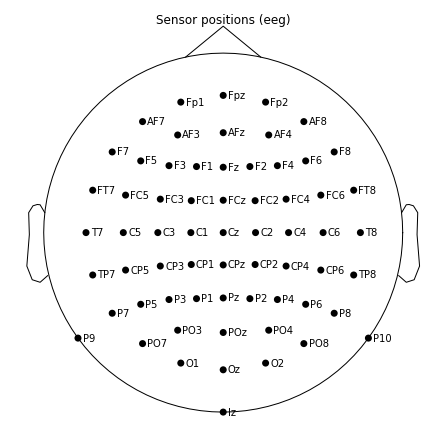

{'EXG1': 'misc', 'EXG2': 'misc', 'EXG3': 'eog', 'EXG4': 'eog', 'EXG5': 'eog', 'EXG6': 'misc', 'EXG7': 'misc'}


In [4]:
biosemi_montage = mne.channels.make_standard_montage('biosemi64')
_ = biosemi_montage.plot()

with open('EXG_channels.json', 'r') as f:
    EXGchannels_dict = json.load(f)
print(EXGchannels_dict)

for name, raw in raw_dict.items():
    raw.set_channel_types(EXGchannels_dict)
    raw.set_montage(biosemi_montage)


AxesSubplot(0.125,0.536818;0.227941x0.343182)
Effective window size : 1.000 (s)
AxesSubplot(0.398529,0.536818;0.227941x0.343182)
Effective window size : 1.000 (s)
AxesSubplot(0.672059,0.536818;0.227941x0.343182)
Effective window size : 1.000 (s)
AxesSubplot(0.125,0.125;0.227941x0.343182)
Effective window size : 1.000 (s)
AxesSubplot(0.398529,0.125;0.227941x0.343182)
Effective window size : 1.000 (s)
AxesSubplot(0.672059,0.125;0.227941x0.343182)
Effective window size : 1.000 (s)


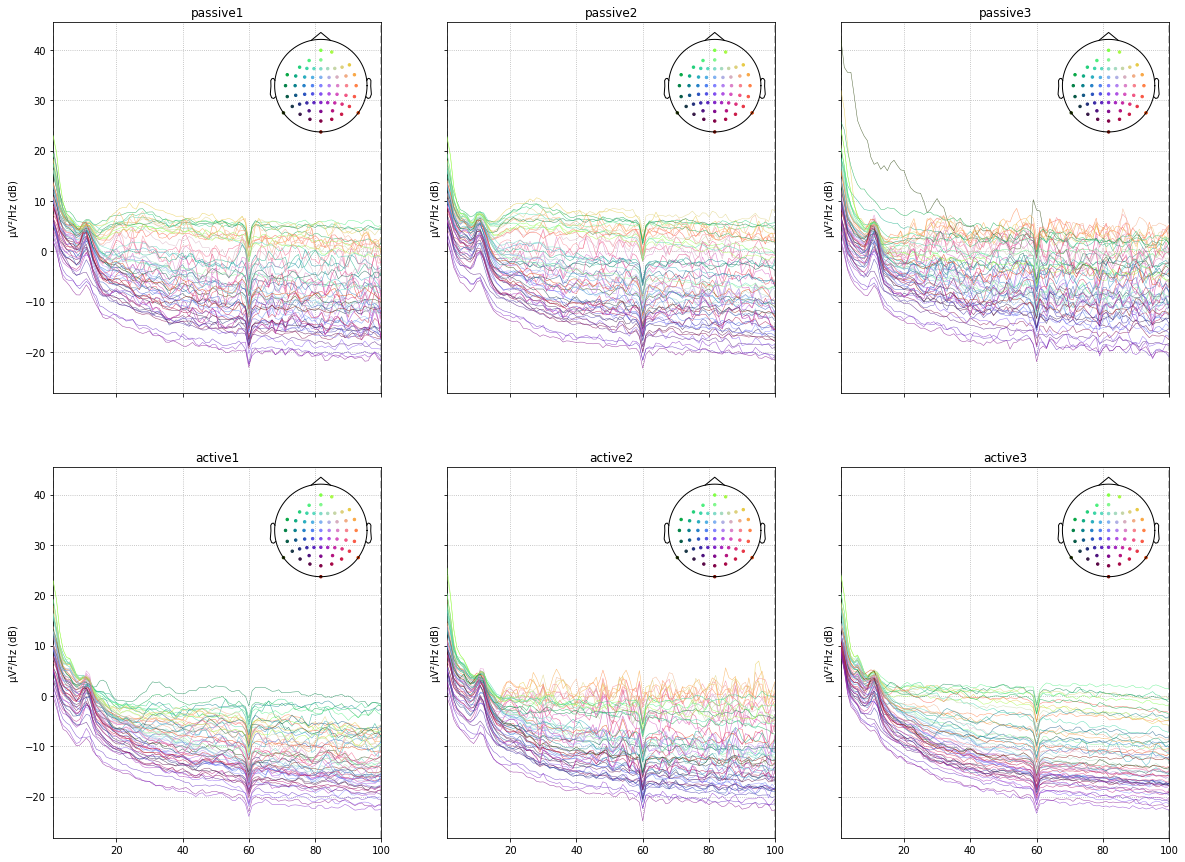

In [5]:
import itertools
for ax, (pa, i) in zip(
    itertools.chain.from_iterable(plt.subplots(nrows=2, ncols=3, figsize=(20,15), sharex=True, sharey=True)[1]),
    itertools.product(['passive', 'active'], [str(i+1) for i in range(3)])
    ):
    name = pa+i
    raw = raw_dict[name]
    print(ax)
    raw.plot_psd(fmin=1., fmax=100., show=False, ax=ax)
    ax.set_title(name)

In [6]:
%%time
def fit_ica(raw, verbose=False):
    ica = mne.preprocessing.ICA(n_components=0.99, verbose=verbose)
    ica.fit(raw, verbose=verbose)
    return ica
with multiprocessing.Pool(processes=1) as pool:#multiprocessing.cpu_count()) as pool:
    ica_dict = collections.OrderedDict(
        [(name, ica) for name, ica in zip(
            raw_dict.keys(),
            pool.imap(fit_ica, raw_dict.values())
        )]
    )

CPU times: user 2.42 s, sys: 3.34 s, total: 5.76 s
Wall time: 7min 46s


In [7]:
excluded_raw_dict = dict()
for name in ica_dict.keys():
    print(name)
    raw, ica = raw_dict[name], ica_dict[name]
    _ = ica.plot_components()#verbose=False)
    _ = ica.plot_properties(raw)#,verbose=False)
    exclude_components = list()
    for exg_name, exg_type in EXGchannels_dict.items():
        if exg_type == 'eog':
            eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=exg_name)
            _ = ica.plot_scores(eog_scores)
            exclude_components.append(numpy.argmax(numpy.abs(eog_scores)))
    _ = ica.plot_overlay(raw, exclude=list(set(exclude_components)), picks='eeg')
    excluded_raw_dict[name] = ica.apply(raw.copy(), exclude=list(set(exclude_components)))

In [8]:
with open('events.json', 'r') as f:
    events_dict = json.load(f)
epochs_dict = {name: mne.Epochs(
    raw,
    mne.find_events(raw),
    event_id=events_dict,
    tmin=-0.4, tmax=0.7,
    reject=dict(
        eeg=200e-6,
#        eog=250e-6,
    ),
    preload=True,
#    verbose=False
) for name, raw in excluded_raw_dict.items()}

In [9]:
for name, epochs in epochs_dict.items():
    _ = epochs.plot_drop_log()

In [10]:
import itertools
for ax, (pa, i) in zip(
    itertools.chain.from_iterable(plt.subplots(nrows=2, ncols=3, figsize=(20,15), sharex=True, sharey=True)[1]),
    itertools.product(['passive', 'active'], [str(i+1) for i in range(3)])
    ):
    name = pa+i
    epochs = epochs_dict[name]
    print(ax)
    epochs.plot_psd(fmin=1., fmax=100., show=False, ax=ax)
    ax.set_title(name)

KeyError: 'passive1'

In [11]:
for name, epochs in epochs_dict.items():
    epochs.save(dir_path/(name+'-epo.fif.gz'))